# 07. Dropout, Recurrent Dropout & Early Stopping — Keras (RNN/LSTM)

Recurrent nets overfit fast. Keras RNN layers take **`dropout`** (on the inputs) and **`recurrent_dropout`** (on the recurrent connections). We pair them with **EarlyStopping** and compare regularized vs not.

**Two datasets, one concept:**
- **A) IMDB** movie reviews — many-to-one *text classification* (metric: accuracy).
- **B) Jena Climate** weather — sliding-window *temperature forecasting* (metric: MAE).

> Data prep lives in `rnn_data.py`; run `01_sequence_data_prep` once to build the caches.

---

## Setup

In [1]:
import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import rnn_data as R                      # shared loaders (see rnn_data.py)
keras.utils.set_random_seed(42)
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

TensorFlow 2.21.0 | Keras 3.14.0


In [2]:
def plot_history(h, metric, title=""):
    """Train (solid) vs validation (dashed): loss on the left, `metric` on the right."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h.history["loss"], label="train")
    ax[0].plot(h.history["val_loss"], "--", label="val")
    ax[0].set_title(title + " — loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h.history[metric], label="train")
    ax[1].plot(h.history["val_" + metric], "--", label="val")
    ax[1].set_title(title + " — " + metric); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## Part A — IMDB: with vs without regularization

`dropout` masks input units; `recurrent_dropout` masks the state-to-state connections (same mask across timesteps). We also add `EarlyStopping`.

In [3]:
Xtr, ytr, Xte, yte = R.load_imdb(); cfg = R.imdb_config()

def build_imdb(reg):
    keras.utils.set_random_seed(42)
    rnn = (layers.LSTM(32, dropout=0.3, recurrent_dropout=0.2) if reg
           else layers.LSTM(32))
    m = keras.Sequential([keras.Input((cfg["maxlen"],)),
                          layers.Embedding(cfg["num_words"], 32), rnn,
                          layers.Dense(1, activation="sigmoid")])
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return m

es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
h_plain = build_imdb(False).fit(Xtr, ytr, validation_data=(Xte, yte),
                                epochs=8, batch_size=64, verbose=0)
h_reg   = build_imdb(True ).fit(Xtr, ytr, validation_data=(Xte, yte),
                                epochs=8, batch_size=64, callbacks=[es], verbose=0)

def gap(h): return h.history["accuracy"][-1] - h.history["val_accuracy"][-1]
print("No reg : test acc %.3f | train-test gap %.3f" % (max(h_plain.history["val_accuracy"]), gap(h_plain)))
print("Reg+ES : test acc %.3f | train-test gap %.3f | stopped at epoch %d"
      % (max(h_reg.history["val_accuracy"]), gap(h_reg), len(h_reg.history["loss"])))

No reg : test acc 0.836 | train-test gap 0.149
Reg+ES : test acc 0.818 | train-test gap 0.107 | stopped at epoch 4


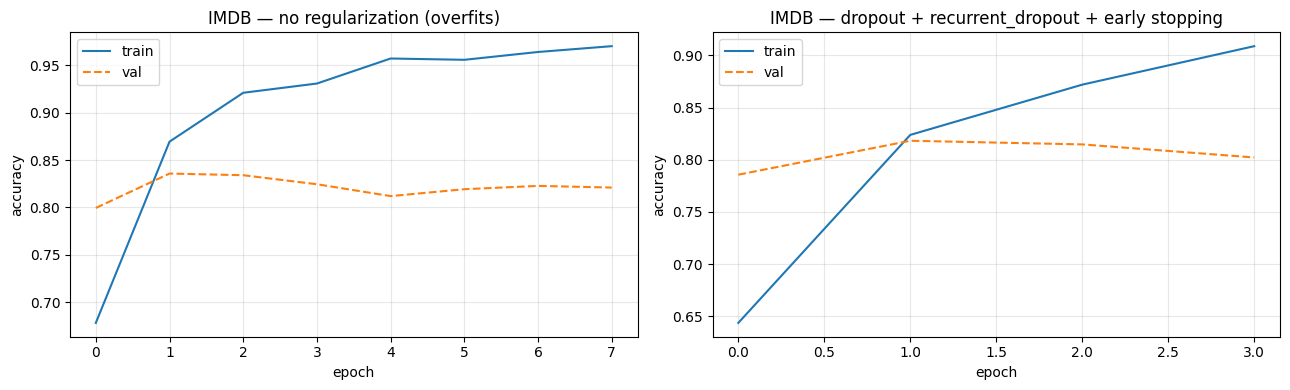

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(h_plain.history["accuracy"], label="train"); ax[0].plot(h_plain.history["val_accuracy"], "--", label="val")
ax[0].set_title("IMDB — no regularization (overfits)")
ax[1].plot(h_reg.history["accuracy"], label="train"); ax[1].plot(h_reg.history["val_accuracy"], "--", label="val")
ax[1].set_title("IMDB — dropout + recurrent_dropout + early stopping")
for a in ax: a.set_xlabel("epoch"); a.set_ylabel("accuracy"); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Part B — Jena: dropout in a forecasting LSTM

In [5]:
train_ds, val_ds, nfeat = R.make_jena_datasets(lookback=48, horizon=1, batch_size=128)
s = R.load_jena_series()

def build_jena(reg):
    keras.utils.set_random_seed(42)
    rnn = (layers.LSTM(32, dropout=0.2, recurrent_dropout=0.2) if reg else layers.LSTM(32))
    m = keras.Sequential([keras.Input((None, nfeat)), rnn, layers.Dense(1)])
    m.compile(optimizer="adam", loss="mse", metrics=["mae"]); return m

es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
h_jp = build_jena(False).fit(train_ds, validation_data=val_ds, epochs=12, verbose=0)
h_jr = build_jena(True ).fit(train_ds, validation_data=val_ds, epochs=12, callbacks=[es], verbose=0)
print("No reg : val MAE %.3f (~%.2f degC)" % (min(h_jp.history["val_mae"]), min(h_jp.history["val_mae"])*s["temp_std"]))
print("Reg+ES : val MAE %.3f (~%.2f degC) | stopped at epoch %d"
      % (min(h_jr.history["val_mae"]), min(h_jr.history["val_mae"])*s["temp_std"], len(h_jr.history["loss"])))

No reg : val MAE 0.105 (~0.91 degC)
Reg+ES : val MAE 0.123 (~1.07 degC) | stopped at epoch 9


## Takeaways
- **`dropout`** and **`recurrent_dropout`** shrink the train–val gap on IMDB — the clearest signature of reduced overfitting.
- `recurrent_dropout` applies the *same* dropout mask at every timestep (variational dropout), which is why it regularizes the recurrent path without destroying the sequence signal. Note it disables the fast cuDNN kernel (irrelevant here — we're CPU-only).
- **EarlyStopping** with `restore_best_weights=True` stops before overfitting and keeps the best epoch — essentially free.
- On the smoother Jena signal, regularization helps less (it barely overfits), but the tooling is identical.
- **Next:** `08_model_comparison`.